# 04 · Final results and model delivery

**Final observed Brier: 0.1222672 · All 70 current submissions scored · Release complete**

The winning late submission combines men’s pooled XGBoost at temperature 0.90 with women’s conference logistic regression, C=1.0, at temperature 1.10. This notebook presents the final observed results, then the distinct retrospective benchmark and reproducible production evidence.

The final winner was selected after observing scores. Explored development seasons and the previously consumed 2022–2025 benchmark are not untouched holdouts. No 2026 tournament outcomes enter fitting or prediction. Routine review reads saved evidence; generation and packaging require separate default-off controls.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from march_mania.notebook_support import table, style
from march_mania.runtime import digest
from march_mania.publication.workflow import benchmark_evidence, benchmark_stage, execution_mode

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
MODE = execution_mode()  # Set "train" to evaluate the current completed 02/03 runs.
if MODE == "train":
    benchmark_stage(ROOT)
FINAL, record = benchmark_evidence(ROOT)
summary = record["summary"]
assert summary["status"] == "completed" and not summary["future_labels_used"]
assert not summary["submission_generated"]
style()


## Final observed outcome

In [2]:
import runpy
from IPython.display import HTML
final_api = runpy.run_path(str(ROOT / "scripts/final_report.py"))
final_summary = final_api["review"](ROOT)
final_scores = final_api["scores"](ROOT)
FINAL_REPORT = ROOT / final_api["REPORT"]
display(HTML('<div style="display:flex;gap:18px;flex-wrap:wrap;font-family:Arial;color:#19324A">'
    '<div style="padding:20px 28px;background:#f3f7f8;border-left:5px solid #008577"><span style="font-size:30px;font-weight:700">0.1222672</span><br>Best observed Brier</div>'
    '<div style="padding:20px 28px;background:#f3f7f8"><span style="font-size:30px;font-weight:700">70 / 70</span><br>Current submissions scored</div>'
    '<div style="padding:20px 28px;background:#f3f7f8"><span style="font-size:30px;font-weight:700">Complete</span><br>Models, predictions and evidence preserved</div></div>'))
table(pd.DataFrame([
    {"Stream":"Men", "Model":"Pooled XGBoost · 120 trees · depth 2", "Retained inputs":"128 per route", "Training games":1575, "Temperature":0.9},
    {"Stream":"Women", "Model":"Conference logistic · C=1.0", "Retained inputs":"16 seeded / 15 seed-free", "Training games":772, "Temperature":1.1}
]))
display(Markdown(f"**Winning CSV:** `{final_summary['best_filename']}`. Both displayed Kaggle columns are **{final_summary['best_brier']:.7f}**. Final fitting ends in 2025; 2020 is excluded. [Exact model and byte lineage](../reports/final_results/summary.json)."))


Stream,Model,Retained inputs,Training games,Temperature
Men,Pooled XGBoost · 120 trees · depth 2,128 per route,1575,0.900000
Women,Conference logistic · C=1.0,16 seeded / 15 seed-free,772,1.100000


**Winning CSV:** `m_pooled_xgboost_t090__w_conference_c100_t110.csv`. Both displayed Kaggle columns are **0.1222672**. Final fitting ends in 2025; 2020 is excluded. [Exact model and byte lineage](../reports/final_results/summary.json).

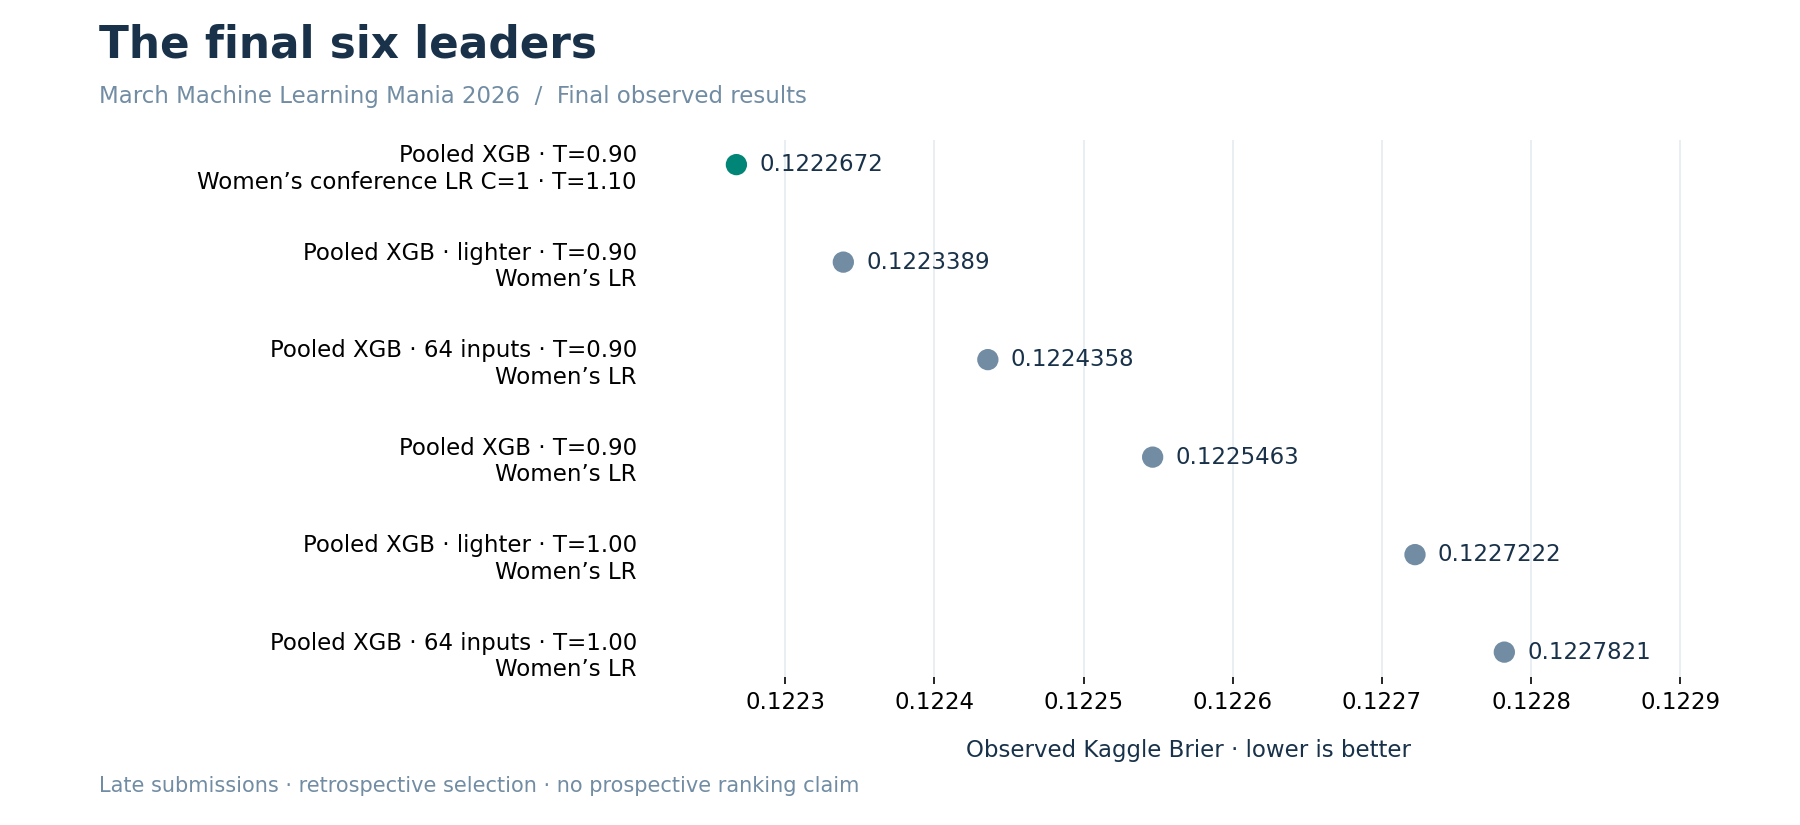

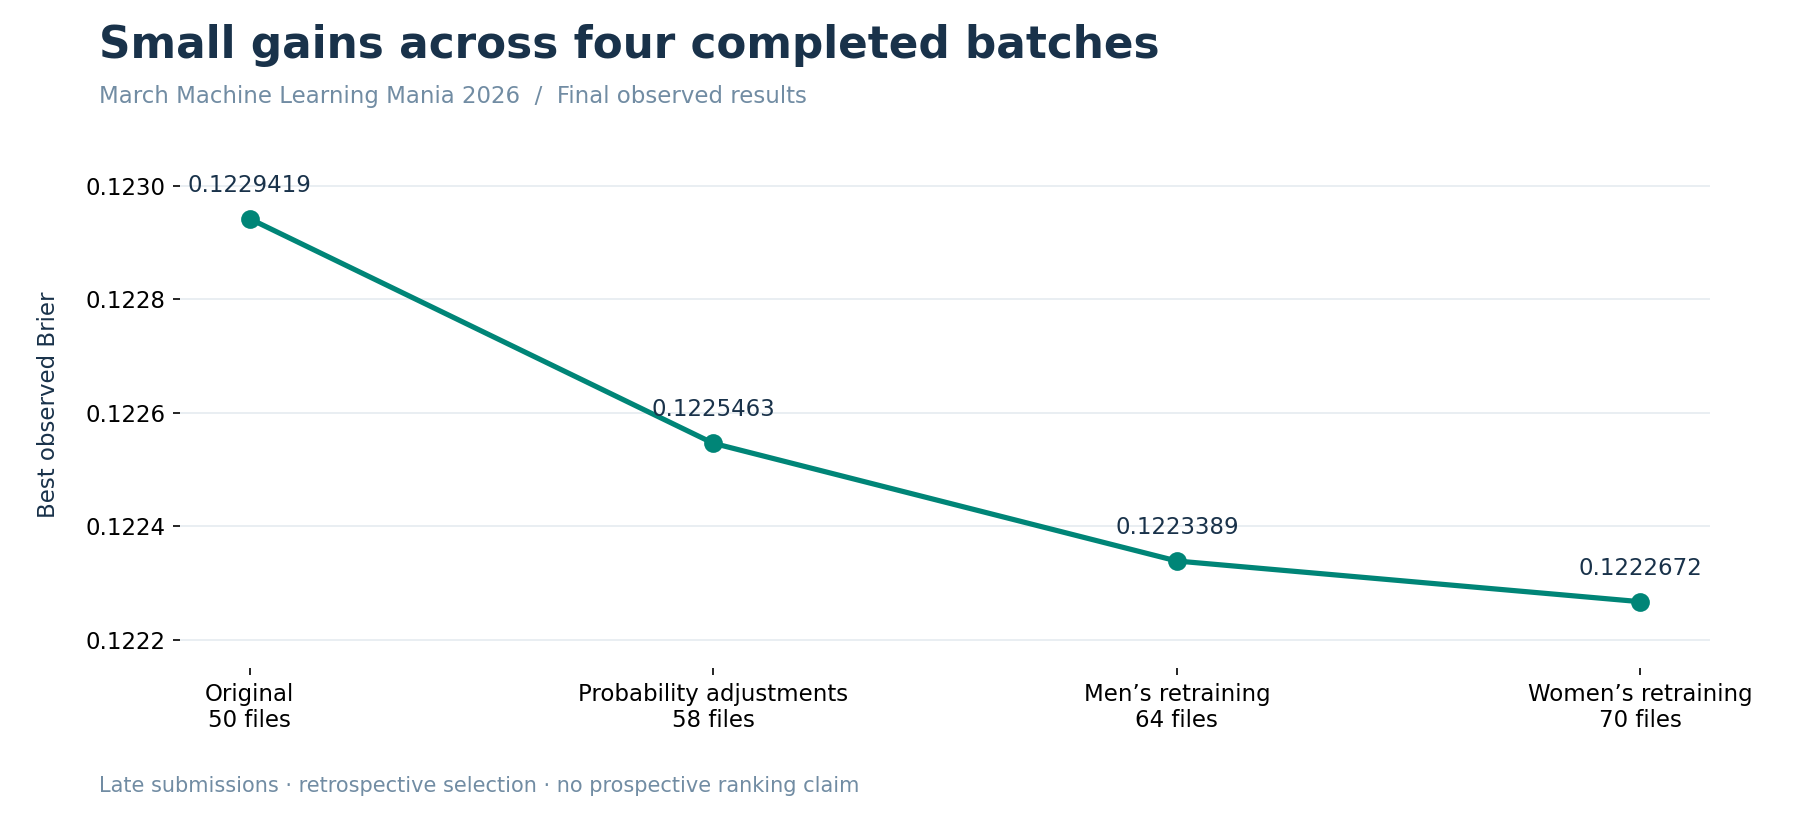

filename,private_brier,public_brier
m_pooled_xgboost_t090__w_conference_c100_t110.csv,0.1222672,0.1222672
m_pooled_xgboost_lighter_t090__w_logistic.csv,0.1223389,0.1223389
m_pooled_xgboost_f064_t090__w_logistic.csv,0.1224358,0.1224358
m_pooled_xgboost_t090__w_logistic.csv,0.1225463,0.1225463
m_pooled_xgboost_lighter_t100__w_logistic.csv,0.1227222,0.1227222
m_pooled_xgboost_f064_t100__w_logistic.csv,0.1227821,0.1227821


The strongest observed result improves Brier by **0.0006747** from the original 50-model batch. Small differences and post-result selection limit the conclusion. The women’s historical priority did not win on Kaggle. [All 70 scores](../reports/final_results/kaggle_scores.csv) · [Self-contained interactive Plotly report](../reports/final_results/results.html).

In [3]:
import base64
final_figures = final_api["figures"](ROOT)
for figure_name in ["leaders", "progression"]:
    display({"application/vnd.plotly.v1+json": json.loads(final_figures[figure_name].to_json()),
             "image/png": base64.b64encode((FINAL_REPORT / f"{figure_name}.png").read_bytes()).decode()}, raw=True)
table(final_scores.head(6)[["filename", "private_brier", "public_brier"]], {"private_brier":"{:.7f}", "public_brier":"{:.7f}"})
display(Markdown("The strongest observed result improves Brier by **0.0006747** from the original 50-model batch. Small differences and post-result selection limit the conclusion. The women’s historical priority did not win on Kaggle. [All 70 scores](../reports/final_results/kaggle_scores.csv) · [Self-contained interactive Plotly report](../reports/final_results/results.html)."))


## Retrospective benchmark: a separate evaluation

The following frozen logistic anchors are evaluated on the already-consumed 2022–2025 benchmark. These metrics describe a different population and protocol from the final Kaggle result above.

## Frozen recipe and training boundaries

The model families and identity calibration follow the predeclared inference contract; notebook 03 separately compares all supported families. Within each logistic family, the feature block and regularization use only saved 2016–2021 development predictions. Every evaluation season is fitted on earlier seasons only. The seed-free route removes every seed-dependent input and uses the same regularization.


In [4]:
display(Markdown(f"**{summary['model_fits']} annual fits · {summary['physical_games']} physical games · retrospective 2022–2025 benchmark**"))
table(pd.DataFrame([{"Stage": stage, "Fingerprint": record["manifest"]["inputs"][key]}
                    for stage, key in [("02 features", "feature_fingerprint"), ("03 models", "model_fingerprint")]]))

recipe = json.loads((FINAL / "recipe.json").read_text())
fits = json.loads((FINAL / "fit_audits.json").read_text())
assert all(r["training_max_season"] < r["prediction_season"] < 2026 for r in fits)
table(pd.DataFrame([{"Tournament": r["gender"], "Route": r["route"],
                     "Evaluated season": r["prediction_season"],
                     "Candidate": r["candidate"]["name"],
                     "Candidates": r["candidate_count"], "Retained": r["retained_count"],
                     "Training games": r["training_games"],
                     "Last training season": r["training_max_season"]} for r in fits]))


**16 annual fits · 536 physical games · retrospective 2022–2025 benchmark**

Stage,Fingerprint
02 features,199b4c00a8b59393a1290727ca6e0e5b9f9bbc5a17db18e1b02354229e5eed89
03 models,20e69d30dc746f39f9395f96d1ff13d7a24cb0a7998fd096a0409c31fa7d7193


Tournament,Route,Evaluated season,Candidate,Candidates,Retained,Training games,Last training season
M,seeded,2022,rank_logistic_1,19,16,535,2021
M,seed_free,2022,rank_logistic_1,18,15,535,2021
M,seeded,2023,rank_logistic_1,19,16,602,2022
M,seed_free,2023,rank_logistic_1,18,15,602,2022
M,seeded,2024,rank_logistic_1,19,16,669,2023
M,seed_free,2024,rank_logistic_1,18,15,669,2023
M,seeded,2025,rank_logistic_1,19,16,736,2024
M,seed_free,2025,rank_logistic_1,18,15,736,2024
W,seeded,2022,logistic_conference_1,18,16,504,2021
W,seed_free,2022,logistic_conference_1,17,15,504,2021


## Retrospective 2022–2025 benchmark

Each season is predicted using only earlier seasons, with the same frozen recipe. The seed-free route is also evaluated on the same tournament games to expose the value of seed information. Its tournament performance does not prove generalization to teams that never qualified.

**Game-weighted Brier** averages every game's squared error. **Mean season Brier** weights seasons equally. Log loss, ROC AUC, average precision and calibration error provide complementary diagnostics. The benchmark was consumed in prior work and is not used to replace the frozen recipe.

The expanded seeded anchors score **0.198288 for men and 0.146881 for women**. The previous 124-feature anchors scored 0.198014 and 0.138599. Neither improves here, and the women regress materially. The new conference block’s development minimum did not establish better benchmark performance. This negative result remains visible without reselecting on the consumed benchmark.

Gender,route,games,brier,mean_season_brier,log_loss,roc_auc,average_precision,ece_10_bins
M,seed_free,268,0.197639,0.197639,0.578065,0.754443,0.795248,0.053146
M,seeded,268,0.198288,0.198288,0.579068,0.751196,0.794644,0.048059
W,seed_free,268,0.148550,0.148550,0.441682,0.870848,0.838521,0.082929
W,seeded,268,0.146881,0.146881,0.438468,0.871468,0.840123,0.066548


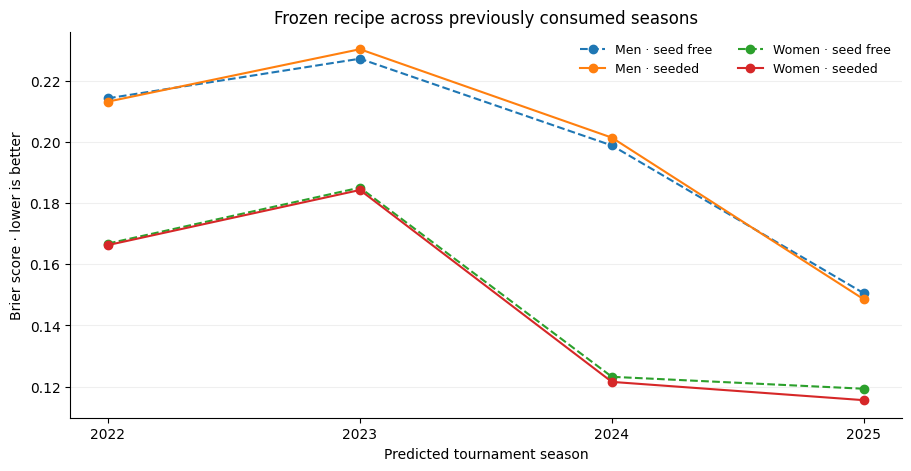

In [5]:
current = pd.read_csv(FINAL / "metrics.csv")
seasonal = pd.read_csv(FINAL / "metrics_by_season.csv")
table(current[["Gender", "route", "games", "brier", "mean_season_brier",
               "log_loss", "roc_auc", "average_precision", "ece_10_bins"]])
fig, ax = plt.subplots(figsize=(9, 4.6), constrained_layout=True)
for (gender, route), group in seasonal.groupby(["Gender", "route"]):
    group = group.sort_values("Season")
    ax.plot(group.Season, group.brier, marker="o",
            linestyle="-" if route == "seeded" else "--",
            label=f"{'Men' if gender == 'M' else 'Women'} · {route.replace('_',' ')}")
ax.set(title="Frozen recipe across previously consumed seasons",
       xlabel="Predicted tournament season", ylabel="Brier score · lower is better",
       xticks=[2022, 2023, 2024, 2025])
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=.2)
ax.legend(frameon=False, ncol=2, fontsize=9)
plt.show()

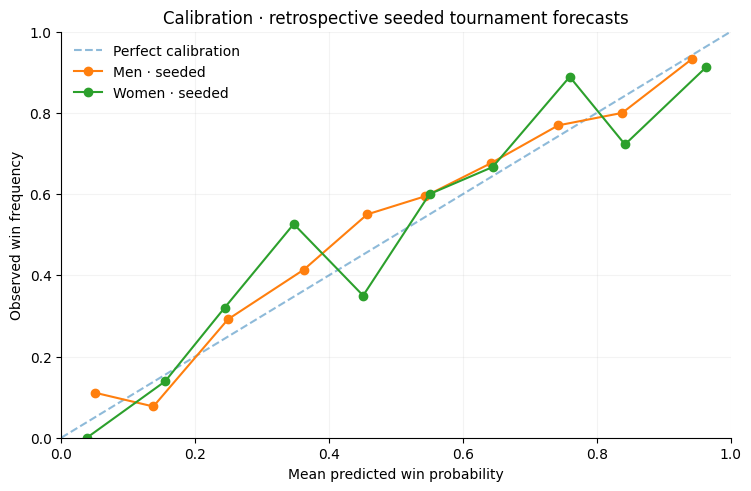

Points summarize ten probability bins. Small bin counts and only four seasons limit precision; proximity to the diagonal is not proof of future calibration. No curve here is used for post-benchmark tuning.

In [6]:
reliability = pd.read_csv(FINAL / "reliability.csv")
fig, ax = plt.subplots(figsize=(7.4, 4.8), constrained_layout=True)
ax.plot([0,1], [0,1], linestyle="--", alpha=.5, label="Perfect calibration")
for gender, group in reliability.loc[reliability.route.eq("seeded")].groupby("Gender"):
    ax.plot(group.predicted, group.observed, marker="o",
            label=f"{'Men' if gender == 'M' else 'Women'} · seeded")
ax.set(title="Calibration · retrospective seeded tournament forecasts",
       xlabel="Mean predicted win probability", ylabel="Observed win frequency",
       xlim=(0,1), ylim=(0,1))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=.15)
ax.legend(frameon=False)
plt.show()
display(Markdown("Points summarize ten probability bins. Small bin counts and only four "
                 "seasons limit precision; proximity to the diagonal is not proof of "
                 "future calibration. No curve here is used for post-benchmark tuning."))

## Evidence and reproducibility

Each of the 16 estimators and 16 prediction batches is checkpointed after its output hashes are recorded. The portable archive preserves the complete audit, development predictions, fitted models, source and feature matrix. The independent model-search recovery test in notebook 03 reports whether a fresh directory reproduces forecasts without repeating fits.

Historical final-submission evidence remains under `reports/final_predictions/` with its original 124-feature lineage. It is not evidence for this expanded experiment.


In [7]:
archive = record["archive"]
assert archive["status"] == "uploaded"
table(pd.DataFrame([{"Run": summary["fingerprint"], "Archive SHA-256": archive["sha256"],
                     "Bytes": archive["bytes"], "Version": archive["version_id"],
                     "Submission generated": summary["submission_generated"],
                     "Kaggle upload sent": summary["kaggle_submission_sent"]}]))
display(Markdown("The archive and exact upstream fingerprints make this evaluation reproducible. The benchmark is descriptive; it does not authorize tuning on these seasons."))


Run,Archive SHA-256,Bytes,Version,Submission generated,Kaggle upload sent
2680bf105e369bbeb1b937d504c8b4f4c8c3772895869acc8b7c5decd0fb9b74,4e243437990b48311238286a9585c83997ea84915a090c44a2ca711845965a01,18070392,Qb.wbPTCFOCmVxk6_C_1_7i32I3T.GeZ,False,False


The archive and exact upstream fingerprints make this evaluation reproducible. The benchmark is descriptive; it does not authorize tuning on these seasons.

## Fifty-file production release

Ten men's procedures crossed with five women's procedures produced **50 distinct complete files**, each containing **132,133 matchups**. Choices and blend weights were frozen from explored pre-2022 development predictions; final training uses 2013–2025, excluding 2020. The reference remains `m_rank_logistic__w_logistic`.

These are retrospective sensitivity candidates. Fifty outputs do not establish fifty independent discoveries or better forecasting accuracy. The **127,577 pairs requiring seed-free features lack matched tournament OOF validation**; their coverage must not be confused with the seeded benchmark above.

This review reads public receipts and file hashes. Restoration and generation remain off by default.


In [8]:
from march_mania.publication import production, production_inputs, production_release

PRODUCTION = ROOT / "reports/prediction_production"
production_summary = production_release.check(ROOT)
production_manifest = pd.read_csv(PRODUCTION / "submission_manifest.csv")
production_archive = json.loads((PRODUCTION / "archive.json").read_text())
production_recovery = json.loads((PRODUCTION / "s3_recovery.json").read_text())
assert production_recovery["archive"] == production_archive
assert production_recovery["checkpoints_reused"] == 344
assert production_recovery["new_fits"] == production_recovery["new_tasks"] == 0
assert production_recovery["submission_files_byte_identical"] == len(production_manifest)
table(pd.DataFrame([{
    "Complete files": production_summary["submission_files"],
    "Rows per file": production_summary["rows_per_file"],
    "Fitted models": production_summary["fitted_models"],
    "Restored checkpoints": production_recovery["checkpoints_reused"],
    "New fits during recovery": production_recovery["new_fits"],
    "Last training season": production_summary["training_max_season"],
    "Kaggle upload sent": production_summary["kaggle_submission_sent"],
}]))
table(pd.read_csv(PRODUCTION / "routes.csv"))
REFERENCE_CANDIDATE = "m_rank_logistic__w_logistic"
table(production_manifest.loc[production_manifest.candidate_id.eq(REFERENCE_CANDIDATE)])
display(Markdown("[All fifty checksums](../reports/prediction_production/submission_manifest.csv) · [Frozen recipe](../reports/prediction_production/recipe.json) · [Remote recovery proof](../reports/prediction_production/s3_recovery.json) · [Employer walkthrough](../docs/employer_walkthrough.md)"))


Complete files,Rows per file,Fitted models,Restored checkpoints,New fits during recovery,Last training season,Kaggle upload sent
50,132133,33,344,0,2025,False


Gender,feature_route,rows
M,seed_free,64152
M,seeded,2278
W,seed_free,63425
W,seeded,2278


candidate_id,path,rows,bytes,sha256
m_rank_logistic__w_logistic,csv_m_rank_logistic__w_logistic/submission.csv,132133,4635537,a4b4e17f1e6f3f2c938e83949872fd463eb3af1fea3ebeea524bc6d745bd51ed


[All fifty checksums](../reports/prediction_production/submission_manifest.csv) · [Frozen recipe](../reports/prediction_production/recipe.json) · [Remote recovery proof](../reports/prediction_production/s3_recovery.json) · [Employer walkthrough](../docs/employer_walkthrough.md)

## Restore the completed files, or run the frozen recipe

Set `RESTORE_PRODUCTION = True` to retrieve the exact private S3 version, verify all saved tasks and display a download link. This needs access to the existing bucket but **no raw inputs or fitting**. Choose any `candidate_id` from the manifest; the default is the reference.

To execute the production pipeline, set `GENERATE_PORTFOLIO = True` instead. It verifies/restores immutable input members and calls the checkpointed runner. An identical completed release reuses its archived checkpoints. Changed production source or environment creates a new run and can require real fitting. Restore and generation are mutually exclusive; both default to off.

Files remain under `outputs/prediction_production/<fingerprint>/csv_<candidate>/submission.csv`. No option sends files to Kaggle.


After either action, a second download provides all fifty CSVs in `submissions/prediction_portfolio.zip`. Each file is named `<candidate_id>.csv` at the ZIP root, for example `m_rank_logistic__w_logistic.csv`. The `m_...` and `w_...` names identify the men's and women's model procedures; the included `recipe.json` records their exact parameters and blend components. The included `submission_manifest.csv` maps each filename to its candidate, original checkpoint path, row count and SHA-256. Every CSV keeps its recorded prediction bytes, and a verified packaging checkpoint is reused on repeat requests.

Extract the ZIP and upload each chosen CSV as a separate Kaggle submission. Uploading this bundle does not submit or score all fifty models together. Use the late-submission allowance currently shown in your Kaggle account.

In [9]:
from IPython.display import HTML

RESTORE_PRODUCTION = False
GENERATE_PORTFOLIO = False
SELECTED_CANDIDATE = "m_rank_logistic__w_logistic"
if RESTORE_PRODUCTION and GENERATE_PORTFOLIO:
    raise ValueError("Choose either archive restoration or production execution")
if SELECTED_CANDIDATE not in set(production_manifest.candidate_id):
    raise ValueError("Choose a candidate_id from the public submission manifest")
if RESTORE_PRODUCTION or GENERATE_PORTFOLIO:
    destination = ROOT / "outputs/prediction_production"
    if RESTORE_PRODUCTION:
        production_run = production_release.recover(ROOT, destination)
    else:
        production_input_dir = ROOT / "outputs/production_inputs"
        try:
            production_inputs.verify(ROOT, production_input_dir)
        except FileNotFoundError:
            production_inputs.restore(ROOT, production_input_dir)
        production_run = production.run(ROOT, production_input_dir, destination)
    verified_files = production_release.verify_tasks(production_run, production_run.name)
    selected = pd.read_csv(production_run / "publication/submission_manifest.csv")
    selected = selected.loc[selected.candidate_id.eq(SELECTED_CANDIDATE)].iloc[0]
    selected_path = production_run / selected.path
    assert digest(selected_path) == verified_files[SELECTED_CANDIDATE]
    import runpy
    delivery = runpy.run_path(str(ROOT / "scripts/deliver_predictions.py"))
    downloads = delivery["package"](ROOT, production_run)
    display(HTML('<a href="../submissions/prediction_portfolio.zip" '
                 'download="prediction_portfolio.zip">Download all 50 prediction files</a>'))
    relative_path = selected_path.relative_to(ROOT).as_posix()
    display(Markdown(f"**{len(verified_files)} complete files verified.** Selected: `{SELECTED_CANDIDATE}`. SHA-256: `{verified_files[SELECTED_CANDIDATE]}`. No Kaggle upload was sent."))
    display(HTML(f'<a href="../{relative_path}" download="{SELECTED_CANDIDATE}.csv">Download selected CSV</a>'))
else:
    display(Markdown("**Restoration and generation are off.** Set `RESTORE_PRODUCTION = True` to retrieve the completed release without fitting."))


**Restoration and generation are off.** Set `RESTORE_PRODUCTION = True` to retrieve the completed release without fitting.

## Optional single-recipe generation from your current 02/03 run

This separate control uses current local research runs. To retrieve the completed fifty-file release, use restoration above.

First run **02 and 03 with `MODE = "train"`**, using your current raw inputs and matching checkpoints. Then set `GENERATE_SUBMISSION = True` below and run the cell. It calls real model refitting/inference when needed, verifies exact template order, probability bounds and team orientation, then writes **`submissions/submission.csv`** atomically. Matching successful fits are reused. It requires the existing AWS role to retain durable checkpoints.

The cell refuses stale feature or model inputs rather than exporting probabilities from an unrelated saved experiment. The recipe is explicit in `configs/inference.json`; the existing logistic recipe is a frozen baseline, not a claim that it wins every later research comparison.

Use the displayed link, or find `submissions/submission.csv` in JupyterLab's file browser and choose **Download**. You decide whether to upload it to Kaggle. There is no upload call in this workflow. This notebook does not create a CSV in review mode.

In [10]:
from IPython.display import HTML
from march_mania.publication.workflow import generate_submission

GENERATE_SUBMISSION = False  # Change to True only when YOU are ready to generate locally.
if GENERATE_SUBMISSION:
    SUBMISSION = generate_submission(ROOT)
    display(Markdown(f"**Your file is ready:** `submissions/submission.csv`  \nSHA-256: `{digest(SUBMISSION)}`. No Kaggle upload was sent."))
    display(HTML('<a href="../submissions/submission.csv" download="submission.csv">Download your submission.csv</a>'))
else:
    display(Markdown("**Export is off.** Set `GENERATE_SUBMISSION = True` to generate and download your own file after 02/03 training."))

**Export is off.** Set `GENERATE_SUBMISSION = True` to generate and download your own file after 02/03 training.

Sources: [official competition and evaluation](https://www.kaggle.com/competitions/march-machine-learning-mania-2026) · exact current benchmark manifests in `reports/benchmark/` · historical [score log](../reports/submission_portfolio/). Local evaluation includes play-ins and is not identical to Kaggle's scored population.


## Observed 2026 Kaggle scores

All 50 files show **Complete (after deadline)** in the owner's screenshots. Public and private Brier match to seven displayed decimals. The score ledger ties every filename to its production checksum. Submission IDs and exact submission timestamps were not supplied.

The production receipts above describe generation before these uploads. The table below records the subsequent scores. These retrospective 2026 results have now been seen.

**Best observed: `m_pooled_xgboost__w_logistic` — Brier 0.1229419.** Women's logistic regression has the lowest combined score with every men's stream.

filename,private_brier,public_brier
m_pooled_xgboost__w_logistic.csv,0.1229419,0.1229419
m_pooled_hist__w_logistic.csv,0.1241702,0.1241702
m_pooled_blend__w_logistic.csv,0.1246834,0.1246834
m_rank_logistic__w_logistic.csv,0.1257070,0.1257070
m_pooled_xgboost__w_xgboost.csv,0.1260063,0.1260063
m_pooled_xgboost__w_hist.csv,0.1260074,0.1260074
m_pooled_xgboost__w_lightgbm.csv,0.1260648,0.1260648
m_pooled_xgboost__w_pooled_logistic.csv,0.1271141,0.1271141
m_pooled_hist__w_xgboost.csv,0.1272346,0.1272346
m_pooled_hist__w_hist.csv,0.1272357,0.1272357


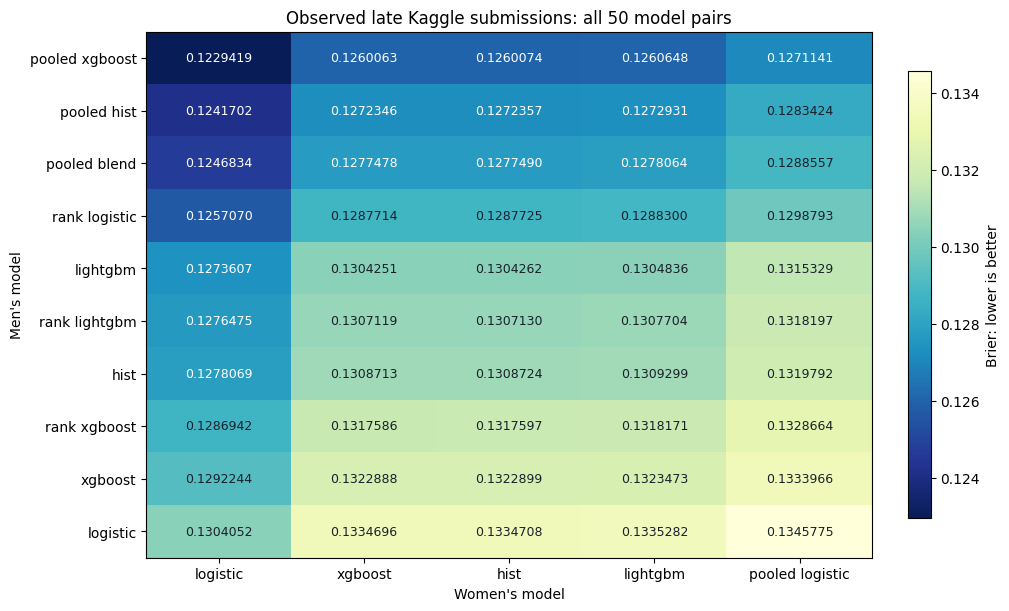

[Complete score ledger](../reports/prediction_refinement/observed_scores.csv) · [Screenshot provenance](../reports/prediction_production/kaggle_scores.json)

In [11]:
from march_mania.publication import refinement

refinement_summary = refinement.review(ROOT)
observed_scores = refinement.score_table(ROOT)
display(Markdown(f"**Best observed: `{refinement_summary['best_observed_candidate']}` — Brier {refinement_summary['best_observed_brier']:.7f}.** Women's logistic regression has the lowest combined score with every men's stream."))
table(observed_scores[['filename', 'private_brier', 'public_brier']].head(10), formats={'private_brier': '{:.7f}', 'public_brier': '{:.7f}'})
score_grid = observed_scores.pivot(index='men_stream', columns='women_stream', values='private_brier')
score_grid = score_grid.loc[score_grid.min(axis=1).sort_values().index, score_grid.mean().sort_values().index]
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
heat = ax.imshow(score_grid, cmap='YlGnBu_r', aspect='auto')
ax.set_xticks(range(len(score_grid.columns)), [s.removeprefix('w_').replace('_', ' ') for s in score_grid.columns])
ax.set_yticks(range(len(score_grid)), [s.removeprefix('m_').replace('_', ' ') for s in score_grid.index])
for i in range(len(score_grid)):
    for j in range(len(score_grid.columns)):
        value = score_grid.iloc[i, j]
        ax.text(j, i, f'{value:.7f}', ha='center', va='center', fontsize=9, color='white' if heat.norm(value) < .43 else '#18202a')
ax.set(title='Observed late Kaggle submissions: all 50 model pairs', xlabel="Women's model", ylabel="Men's model")
fig.colorbar(heat, ax=ax, label='Brier: lower is better', shrink=.85)
plt.show()
display(Markdown('[Complete score ledger](../reports/prediction_refinement/observed_scores.csv) · [Screenshot provenance](../reports/prediction_production/kaggle_scores.json)'))

## Eight adjustments after observing the results

The best observed pair motivates eight sensitivity candidates. Women's logistic predictions stay unchanged. Men's pooled XGBoost is mixed with either ranked logistic regression or pooled histogram boosting at 25%, 50% and 75% XGBoost weight. Two additional variants use temperature 0.90 (sharper) and 1.10 (softer).

The checks below use 649 aligned historical games from 2016–2019 and 2021. Every base procedure used earlier-season model selection. These years were previously explored, and the hypotheses followed the 2026 scores. This is not a new untouched holdout or validation of the final fitted estimators. The original frozen recipe is retained. The adjustments require zero new model fits.

candidate_id,brier,mean_season_brier,log_loss,brier_delta_vs_anchor,improved_seasons,worst_season_delta
m_pooled_xgboost50_rank_logistic50__w_logistic,0.166321,0.166341,0.492811,-0.000899,3,0.003225
m_pooled_xgboost75_rank_logistic25__w_logistic,0.166542,0.166561,0.493046,-0.000678,4,0.001403
m_pooled_xgboost25_rank_logistic75__w_logistic,0.166557,0.166578,0.493678,-0.000663,3,0.005464
m_pooled_xgboost_t110__w_logistic,0.167057,0.167075,0.494475,-0.000163,4,0.000180
m_pooled_xgboost75_pooled_hist25__w_logistic,0.167248,0.167267,0.494585,0.000028,2,0.000275
m_pooled_xgboost50_pooled_hist50__w_logistic,0.167310,0.167328,0.494830,0.000090,1,0.000588
m_pooled_xgboost25_pooled_hist75__w_logistic,0.167404,0.167423,0.495163,0.000184,1,0.000937
m_pooled_xgboost_t090__w_logistic,0.167720,0.167738,0.495503,0.000500,0,0.000723


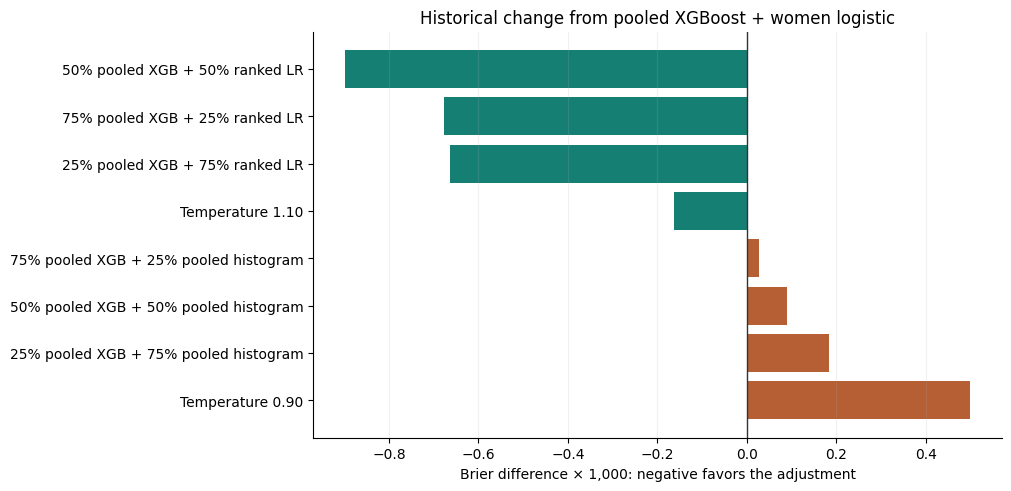

The **50/50 pooled XGBoost–ranked logistic mixture** has the lowest historical Brier, **0.166321 versus 0.167220** for the anchor, improving 3 of 5 seasons. The 75/25 mixture improves 4 of 5 seasons. Pooled-histogram mixtures and temperature 0.90 do not improve aggregate historical Brier. They remain sensitivity controls. **The observed scores for all eight adjustments are recorded below. Temperature 0.90 wins on the observed 2026 results despite worsening historical Brier.**

In [12]:
historical_adjustments = pd.read_csv(ROOT / refinement.REPORT / 'historical_catalog.csv')
new_adjustments = historical_adjustments.loc[historical_adjustments.is_new_adjustment].copy()
table(new_adjustments[['candidate_id', 'brier', 'mean_season_brier', 'log_loss', 'brier_delta_vs_anchor', 'improved_seasons', 'worst_season_delta']])
config = json.loads((ROOT / refinement.CONFIG).read_text())
labels = {}
for v in config['variants']:
    if v['kind'] == 'temperature':
        labels[v['candidate_id']] = f"Temperature {v['temperature']:.2f}"
    else:
        partner = 'ranked LR' if v['partner'] == 'm_rank_logistic' else 'pooled histogram'
        labels[v['candidate_id']] = f"{v['anchor_weight']:.0%} pooled XGB + {1-v['anchor_weight']:.0%} {partner}"
fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
deltas = new_adjustments.brier_delta_vs_anchor.to_numpy()
ax.barh([labels[s] for s in new_adjustments.candidate_id], deltas*1000, color=['#167f74' if d < 0 else '#b65f34' for d in deltas])
ax.axvline(0, color='#333333', linewidth=1)
ax.invert_yaxis()
ax.set(title='Historical change from pooled XGBoost + women logistic', xlabel='Brier difference × 1,000: negative favors the adjustment')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=.18)
plt.show()
display(Markdown('The **50/50 pooled XGBoost–ranked logistic mixture** has the lowest historical Brier, **0.166321 versus 0.167220** for the anchor, improving 3 of 5 seasons. The 75/25 mixture improves 4 of 5 seasons. Pooled-histogram mixtures and temperature 0.90 do not improve aggregate historical Brier. They remain sensitivity controls. **The observed scores for all eight adjustments are recorded below. Temperature 0.90 wins on the observed 2026 results despite worsening historical Brier.**'))

## Generate and download the eight adjustments

Set `GENERATE_REFINEMENT = True` to create eight named CSVs from the exact saved source ZIP. If needed, enable `RESTORE_PRODUCTION` above first. Completed generation is reused after checksum verification. All original predictions and model recipes are preserved. Extract the new ZIP and upload each chosen model CSV separately. The manifest and recipe are provenance files.

In [13]:
GENERATE_REFINEMENT = False
if GENERATE_REFINEMENT:
    refinement_receipt = refinement.generate(ROOT, ROOT / 'submissions/prediction_portfolio.zip')
    display(Markdown(f"**{refinement_receipt['submission_files']} files verified**, each with {refinement_receipt['rows_per_file']:,} rows. New model fits: 0."))
    display(HTML('<a href="../submissions/prediction_refinement.zip" download="prediction_refinement.zip">Download the eight adjustment candidates</a>'))
else:
    display(Markdown('**Generation is off.** See the [completed generation audit](../reports/prediction_refinement/generation.json). Set `GENERATE_REFINEMENT = True` to reproduce the named ZIP.'))

**Generation is off.** See the [completed generation audit](../reports/prediction_refinement/generation.json). Set `GENERATE_REFINEMENT = True` to reproduce the named ZIP.

## Complete submission history and the eight new observations

All **58 current CSVs** now have recorded late Kaggle scores, with matching public and private values to seven decimals. The temperature-0.90 adjustment scores **0.1225463**, improving the original pooled-XGBoost/women-logistic score of **0.1229419** by **0.0003956**. Its historical score worsened, so the observed improvement does not prove better generalization. Subsequent comparisons remain retrospective.

The collection preserves the exact bytes of all 50 original and eight adjusted predictions, their checksums, recipes and score provenance. The separate 18-row legacy score history is also retained; legacy prediction binaries are not part of this 58-file collection. No prediction is regenerated to archive it.


In [14]:
from march_mania.publication import scoreboard
score_summary = scoreboard.review(ROOT)
all_scores = scoreboard.scores(ROOT)
table(all_scores.loc[all_scores.batch.eq("refinement_8"), ["filename", "private_brier", "public_brier"]], {"private_brier": "{:.7f}", "public_brier": "{:.7f}"})
table(all_scores.head(10)[["filename", "batch", "private_brier"]], {"private_brier": "{:.7f}"})
collection = json.loads((ROOT / scoreboard.REPORT / "collection.json").read_text())
assert collection["files"] == score_summary["current_submission_files"] == 58
assert collection["prediction_bytes_unchanged"]
display(Markdown(f"**Archived collection:** {collection['files']} files × {collection['rows_per_file']:,} rows. **Best observed Brier:** {score_summary['best_brier']:.7f}."))
PACKAGE_SUBMISSIONS = False
if PACKAGE_SUBMISSIONS:
    # Restore the original archive and generate/recover the eight adjustments above first.
    scoreboard.package(ROOT, ROOT / "submissions/prediction_portfolio.zip", ROOT / "submissions/prediction_refinement.zip")
    display(HTML('<a href="../submissions/submission_collection.zip" download="submission_collection.zip">Download all 58 current submissions and score history</a>'))
else:
    display(Markdown("**Packaging is off.** The completed archive and each original CSV checksum are recorded in [the score report](../reports/submission_scores/README.md)."))


filename,private_brier,public_brier
m_pooled_xgboost_t090__w_logistic.csv,0.1225463,0.1225463
m_pooled_xgboost75_rank_logistic25__w_logistic.csv,0.1231137,0.1231137
m_pooled_xgboost75_pooled_hist25__w_logistic.csv,0.1232226,0.1232226
m_pooled_xgboost50_pooled_hist50__w_logistic.csv,0.1235209,0.1235209
m_pooled_xgboost_t110__w_logistic.csv,0.1235803,0.1235803
m_pooled_xgboost50_rank_logistic50__w_logistic.csv,0.1236319,0.1236319
m_pooled_xgboost25_pooled_hist75__w_logistic.csv,0.1238368,0.1238368
m_pooled_xgboost25_rank_logistic75__w_logistic.csv,0.1244963,0.1244963


filename,batch,private_brier
m_pooled_xgboost_t090__w_logistic.csv,refinement_8,0.1225463
m_pooled_xgboost__w_logistic.csv,original_50,0.1229419
m_pooled_xgboost75_rank_logistic25__w_logistic.csv,refinement_8,0.1231137
m_pooled_xgboost75_pooled_hist25__w_logistic.csv,refinement_8,0.1232226
m_pooled_xgboost50_pooled_hist50__w_logistic.csv,refinement_8,0.1235209
m_pooled_xgboost_t110__w_logistic.csv,refinement_8,0.1235803
m_pooled_xgboost50_rank_logistic50__w_logistic.csv,refinement_8,0.1236319
m_pooled_xgboost25_pooled_hist75__w_logistic.csv,refinement_8,0.1238368
m_pooled_hist__w_logistic.csv,original_50,0.1241702
m_pooled_xgboost25_rank_logistic75__w_logistic.csv,refinement_8,0.1244963


**Archived collection:** 58 files × 132,133 rows. **Best observed Brier:** 0.1225463.

**Packaging is off.** The completed archive and each original CSV checksum are recorded in [the score report](../reports/submission_scores/README.md).

## Six retrained challengers for manual submission

The owner requested a bounded batch from the strongest historical challengers: **64 retained features**, **lighter regularization**, and **240 trees**. Each pooled XGBoost model has raw probabilities (temperature 1.00) and a fixed temperature-0.90 variant. The 64-feature pair was the initial historical priority; the lighter model at temperature 0.90 subsequently led this men’s batch. The confidence adjustment is motivated by the already-observed 2026 result, not independent calibration evidence.

All six use the exact existing women's logistic prediction bytes. Final fitting uses 2013–2025 tournament games, excluding canceled 2020, with separate seeded and seed-free routes. No 2026 tournament outcome enters fitting, screening, or prediction. These common pooled models do not use Massey features; the matched Massey and coach comparisons remain in notebook 03.

This men’s batch brought the inventory to **64 generated prediction CSVs at that stage**; the women’s batch below adds six more. The prior 58-file archive and all recorded scores remain preserved. Historical men's Brier values and observed combined Kaggle scores are labeled separately below.


In [15]:
from march_mania.publication import challengers
challenger_summary = challengers.review(ROOT)
challenger_manifest = pd.read_csv(ROOT / challengers.REPORT / "submission_manifest.csv")
study_scores = pd.read_csv(ROOT / "reports/xgboost_retraining/leaderboard.csv")
challenger_table = challenger_manifest.merge(
    study_scores[["variant", "brier", "mean_season_brier"]],
    on="variant", validate="many_to_one"
).sort_values("priority")
challenger_table = challenger_table.merge(final_scores[["filename", "private_brier"]], on="filename", validate="one_to_one")
challenger_table["status"] = "Scored"
table(challenger_table[["priority", "filename", "temperature", "status", "private_brier", "brier", "mean_season_brier"]],
      {"private_brier": "{:.7f}", "brier": "{:.6f}", "mean_season_brier": "{:.6f}"})
display(Markdown("Historical metrics describe the unadjusted recipe; both temperatures share that recipe's historical row. All six files were subsequently scored; the observed score column is joined from the final ledger."))
fit_audits = json.loads((ROOT / challengers.REPORT / "fit_audits.json").read_text())
table(pd.DataFrame([{
    "Variant": a["variant"], "Route": a["route"], "Training games": a["training_games"],
    "Last training season": a["training_max_season"], "Retained features": len(a["retained_features"]),
    "Reload difference": a["reload_max_absolute_error"]
} for a in fit_audits]))
display(Markdown(f"**{challenger_summary['submission_files']} distinct files × {challenger_summary['rows_per_file']:,} rows.** Six estimators fitted; women's rows unchanged. [Manifest and checksums](../reports/prediction_challengers/submission_manifest.csv)."))


priority,filename,temperature,status,private_brier,brier,mean_season_brier
1,m_pooled_xgboost_f064_t090__w_logistic.csv,0.900000,Scored,0.1224358,0.184333,0.184403
2,m_pooled_xgboost_f064_t100__w_logistic.csv,1.000000,Scored,0.1227821,0.184333,0.184403
3,m_pooled_xgboost_lighter_t090__w_logistic.csv,0.900000,Scored,0.1223389,0.185088,0.185155
4,m_pooled_xgboost_lighter_t100__w_logistic.csv,1.000000,Scored,0.1227222,0.185088,0.185155
5,m_pooled_xgboost_trees240_t090__w_logistic.csv,0.900000,Scored,0.1245508,0.185116,0.185166
6,m_pooled_xgboost_trees240_t100__w_logistic.csv,1.000000,Scored,0.1244650,0.185116,0.185166


Historical metrics describe the unadjusted recipe; both temperatures share that recipe's historical row. All six files were subsequently scored; the observed score column is joined from the final ledger.

Variant,Route,Training games,Last training season,Retained features,Reload difference
pooled_64_features,seeded,1575,2025,64,0.000000
pooled_64_features,seed_free,1575,2025,64,0.000000
pooled_less_regularized,seeded,1575,2025,128,0.000000
pooled_less_regularized,seed_free,1575,2025,128,0.000000
pooled_240_trees,seeded,1575,2025,128,0.000000
pooled_240_trees,seed_free,1575,2025,128,0.000000


**6 distinct files × 132,133 rows.** Six estimators fitted; women's rows unchanged. [Manifest and checksums](../reports/prediction_challengers/submission_manifest.csv).

## Reproduce the challenger ZIP

Generation remains an explicit action. Restore the original 50-file archive above to obtain the women's baseline, then set `GENERATE_CHALLENGERS = True`. The runner restores only verified input members as needed, checkpoints each final fit and prediction chunk, and reuses completed work with matching hashes. The six files are packaged at the ZIP root in priority order.

Extract `prediction_challengers.zip` and upload each model CSV separately. The manifest and recipe are provenance files.


In [16]:
GENERATE_CHALLENGERS = False
if GENERATE_CHALLENGERS:
    challenger_inputs = ROOT / "outputs/retraining_inputs"
    try:
        production_inputs.verify(ROOT, challenger_inputs)
    except FileNotFoundError:
        production_inputs.restore(ROOT, challenger_inputs)
    challenger_summary = challengers.generate(
        ROOT, challenger_inputs, ROOT / "submissions/prediction_portfolio.zip"
    )
    display(HTML('<a href="../submissions/prediction_challengers.zip" download="prediction_challengers.zip">Download the six challenger CSVs</a>'))
else:
    display(Markdown("**Generation is off.** The [completed challenger report](../reports/prediction_challengers/README.md) records exact filenames, checksums, final fits, and archive recovery locations."))


**Generation is off.** The [completed challenger report](../reports/prediction_challengers/README.md) records exact filenames, checksums, final fits, and archive recovery locations.

## Six women’s challengers for manual submission

The women’s comparison in notebook 03 adds **six subsequently scored CSVs**. All retain the exact men’s rows from `m_pooled_xgboost_t090__w_logistic.csv`, the best observed combined result at **0.1225463**. This makes changes in the next Kaggle scores attributable to women’s predictions.

Historical priority 1 was the existing conference model at temperature 1.10; the subsequently observed winner was priority 3, C=1.0 at temperature 1.10. The next alternatives test stronger regularization, weaker regularization and the dynamic feature block. Historical differences are small; ranks below are not new Kaggle scores. Final fitting uses only women’s 2013–2025 tournament outcomes, excluding 2020. The three selected new raw recipes have seeded and seed-free estimators; the original C=0.30 conference predictions reuse the exact saved CSV. The seed-free route has no matched tournament validation.

There are now **70 current CSVs, all now scored**. All 64 earlier files remain preserved in their original archives. Extract the ZIP and upload individual model CSVs; the manifest and recipe are provenance records.


In [17]:
import runpy
women_api = runpy.run_path(str(ROOT / "scripts/women_challengers.py"))
GENERATE_WOMEN_CHALLENGERS = False
if GENERATE_WOMEN_CHALLENGERS:
    women_inputs = ROOT / "outputs/retraining_inputs"
    try:
        production_inputs.verify(ROOT, women_inputs)
    except FileNotFoundError:
        production_inputs.restore(ROOT, women_inputs)
    # Restore/recreate the exact eight-refinement ZIP above before this explicit action.
    women_api["generate"](ROOT, women_inputs, ROOT / "submissions/prediction_refinement.zip")
    display(HTML('<a href="../submissions/women_challengers.zip" download="women_challengers.zip">Download six women’s challenger CSVs</a>'))
women_generation = women_api["check_generation"](ROOT)
women_report = ROOT / women_api["REPORT"]
women_manifest = pd.read_csv(women_report / "submission_manifest.csv")
women_finalists = pd.read_csv(women_report / "finalists.csv")
women_table = women_manifest.merge(women_finalists[["candidate_id", "brier", "mean_season_brier"]], on="candidate_id", validate="one_to_one")
women_table = women_table.merge(final_scores[["filename", "private_brier"]], on="filename", validate="one_to_one")
women_table["status"] = "Scored"
table(women_table[["priority", "filename", "status", "private_brier", "brier", "mean_season_brier"]], {"private_brier": "{:.7f}", "brier": "{:.6f}", "mean_season_brier": "{:.6f}"})
assert women_generation["men_predictions_unchanged"]
display(Markdown(f"**{women_generation['submission_files']} distinct CSVs × {women_generation['rows_per_file']:,} rows.** Six final estimators fitted through 2025; no 2026 labels used. **Generation is {'on' if GENERATE_WOMEN_CHALLENGERS else 'off'}.** [Checksums, recovery and saved artifacts](../reports/women_challengers/README.md)."))


priority,filename,status,private_brier,brier,mean_season_brier
1,m_pooled_xgboost_t090__w_conference_c030_t110.csv,Scored,0.1231223,0.142167,0.142167
2,m_pooled_xgboost_t090__w_conference_c010_t110.csv,Scored,0.1245764,0.142881,0.142881
3,m_pooled_xgboost_t090__w_conference_c100_t110.csv,Scored,0.1222672,0.142958,0.142958
4,m_pooled_xgboost_t090__w_dynamic_c030_t110.csv,Scored,0.1265330,0.143116,0.143116
5,m_pooled_xgboost_t090__w_conference_c010_t100.csv,Scored,0.1240335,0.143331,0.143331
6,m_pooled_xgboost_t090__w_dynamic_c030_t100.csv,Scored,0.1262489,0.143867,0.143867


**6 distinct CSVs × 132,133 rows.** Six final estimators fitted through 2025; no 2026 labels used. **Generation is off.** [Checksums, recovery and saved artifacts](../reports/women_challengers/README.md).

## Completed collection and reproducibility

All 70 CSVs retain their original bytes and unique model filenames. The consolidated ZIP adds the complete score ledger and final model record. Packaging reuses the three existing archives and verified checkpoints; it does not fit models or upload to Kaggle. The original generation-time manifests remain immutable, and the final observed ledger records the subsequent scores.


In [18]:
PACKAGE_FINAL_COLLECTION = False
if PACKAGE_FINAL_COLLECTION:
    final_api["package"](ROOT, [
        ROOT / "submissions/submission_collection.zip",
        ROOT / "submissions/prediction_challengers.zip",
        ROOT / "submissions/women_challengers.zip"
    ])
    display(HTML('<a href="../submissions/final_submissions.zip" download="final_submissions.zip">Download all 70 scored submission CSVs</a>'))
collection = json.loads((FINAL_REPORT / "collection.json").read_text())
assert collection["files"] == 70 and collection["new_model_fits"] == 0
assert collection["prediction_bytes_unchanged"]
display(Markdown("**Release complete.** All scores, exact prediction bytes and fitted model artifacts are preserved. [Collection and storage records](../reports/final_results/README.md#delivery-and-recovery). Further model exploration or a future tournament would be a separate research extension."))


**Release complete.** All scores, exact prediction bytes and fitted model artifacts are preserved. [Collection and storage records](../reports/final_results/README.md#delivery-and-recovery). Further model exploration or a future tournament would be a separate research extension.